In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam



In [ ]:
# Data creation
X, y = make_circles(n_samples=1000, noise=0.05, factor=0.5, random_state=42)



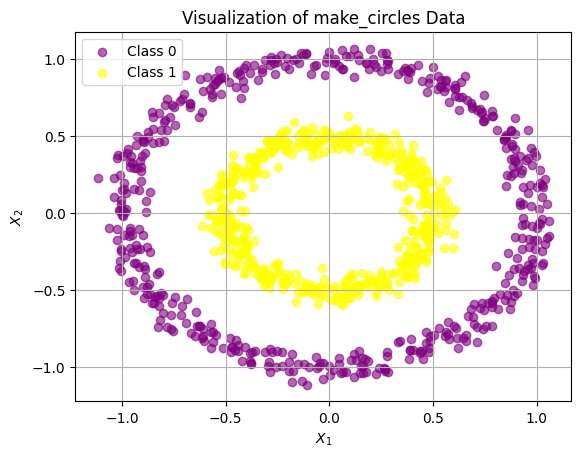

In [ ]:
# Create a scatter plot
plt.scatter(X[y == 0, 0], X[y == 0, 1], label='Class 0', alpha=0.6,color = 'purple')
plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Class 1', alpha=0.6, color = 'yellow')
plt.title('Visualization of make_circles Data')
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.legend()
plt.grid(True)


In [ ]:
def plot_graph(model, X, y, title):
    # Step 1: Create a grid (the background map) from -1.5 to 1.5
    # We use 100 points for x and 100 points for y
    grid = np.linspace(-1.5, 1.5, 100)
    xx, yy = np.meshgrid(grid, grid)

    # Step 2: Flatten the grid to pass it into the model
    # ".ravel()" flattens the array, "np.column_stack" puts them together
    all_points = np.column_stack([xx.ravel(), yy.ravel()])

    # Step 3: Predict the color for every point on the grid
    preds = model.predict(all_points, verbose=0)
    Z = preds.round().reshape(xx.shape)

    # Step 4: Draw the background colors and the actual data dots
    plt.contourf(xx, yy, Z, alpha=0.3)            # Background
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k') # Data dots
    plt.title(title)

In [ ]:

# ==========================================
# 2. Model A: Single Layer Perceptron (SLP)
# ==========================================
print("Training Single Layer Perceptron (Linear)...")

# A single layer with 1 neuron and sigmoid is essentially Logistic Regression
slp_model = Sequential([
    Dense(1, input_shape=(2,), activation='sigmoid')
])

slp_model.compile(loss='binary_crossentropy', metrics=['accuracy'])
slp_model.fit(X, y, epochs=50, verbose=1)



Training Single Layer Perceptron (Linear)...
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4842 - loss: 0.7789   
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5047 - loss: 0.7624 
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4920 - loss: 0.7519
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5065 - loss: 0.7553 
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5071 - loss: 0.7537
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5100 - loss: 0.7460 
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5011 - loss: 0.7494 
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5267 - loss: 0.7304 
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5058 - loss: 0.7352 
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5340 - loss: 0.7239 
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4958 - loss: 0.7286 
Epoch 12/50
32/32 

In [ ]:
# Calculate final accuracy
slp_loss, slp_acc = slp_model.evaluate(X, y, verbose=0)
print(f"SLP Accuracy: {slp_acc*100:.2f}%")

SLP Accuracy: 50.60%


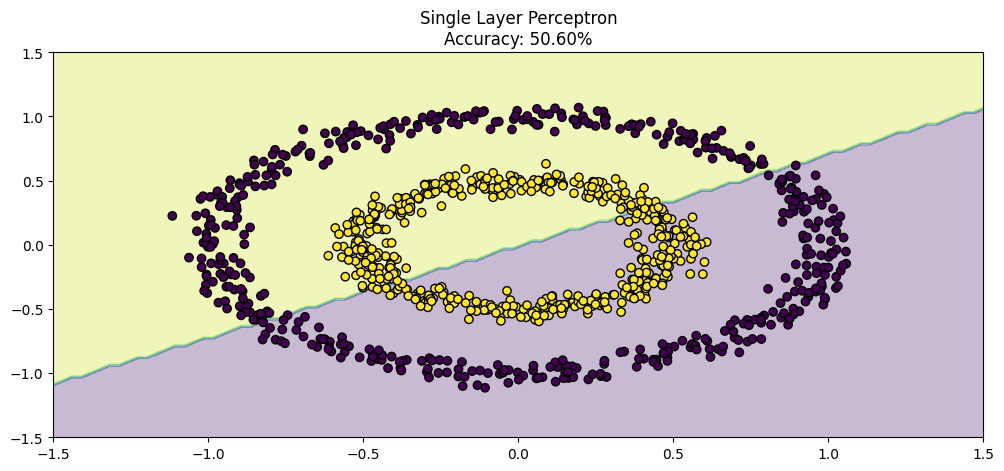

In [ ]:
plt.figure(figsize=(12, 5))

plot_graph(slp_model, X, y, title=f"Single Layer Perceptron\nAccuracy: {slp_acc*100:.2f}%")


In [ ]:
# ==========================================
# 3. Model B: Multi-Layer Perceptron (Deep Neural Network)
# ==========================================
print("Training Multi-Layer Perceptron (Non-Linear)...")

# Adding hidden layers with ReLU activation introduces non-linearity
mlp_model = Sequential([
    Dense(16, input_shape=(2,), activation='relu'), # Hidden Layer 1
    Dense(16, activation='relu'),                   # Hidden Layer 2
    Dense(1, activation='sigmoid')                  # Output Layer
])

mlp_model.compile(loss='binary_crossentropy', metrics=['accuracy'])
mlp_history = mlp_model.fit(X, y, epochs=50, verbose=1)



Training Multi-Layer Perceptron (Non-Linear)...
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5021 - loss: 0.6682   
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5111 - loss: 0.6538
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5311 - loss: 0.6313
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5713 - loss: 0.6125
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6964 - loss: 0.5818
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8430 - loss: 0.5581
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9174 - loss: 0.5131
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9676 - loss: 0.4754
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9980 - loss: 0.4231
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.3862
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.3397
Epoch 12/50
32/32 ━━━━━

In [ ]:
# Calculate final accuracy
mlp_loss, mlp_acc = mlp_model.evaluate(X, y, verbose=0)
print(f"MLP Accuracy: {mlp_acc*100:.2f}%")

MLP Accuracy: 100.00%


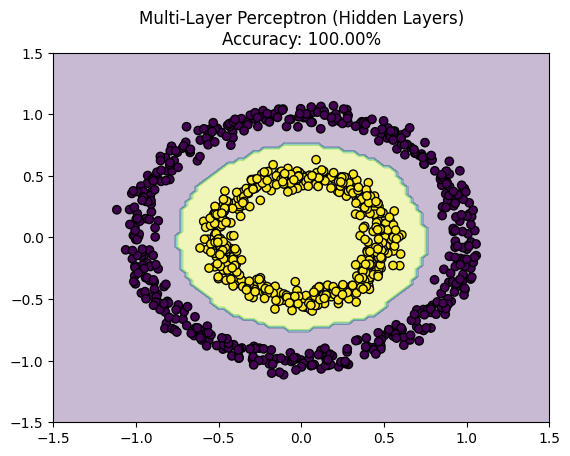

In [ ]:
# ==========================================
# 4. Plotting Results
# ==========================================

# Plot MLP Results

plot_graph(mlp_model, X, y, title=f"Multi-Layer Perceptron (Hidden Layers)\nAccuracy: {mlp_acc*100:.2f}%")

plt.show()